# Hotel Revenue & Booking Analytics
### A synthetic hospitality portfolio reconstruction

> This is a portfolio reconstruction based on analytical workflows used in a real hospitality setting. All data in this repository is synthetic and does not contain customer or proprietary business information.

**Decision context:** a small hotel wants to understand when rooms sell, which room types contribute revenue, and where to test pricing changes. This walkthrough moves from an imperfect booking export to validated metrics and cautious business recommendations.

**Scope:** 2023–2025 · 18 rooms · illustrative USD · one room per booking · no external data.

The original business data and code are unavailable. These are newly created analytical examples, not historical company results.

## 1. Set up the analysis

Run from the repository root or `notebooks/`. The raw CSV is committed, so this notebook can be executed after installing `requirements-notebook.txt`. It uses the same functions as the command-line pipeline.

In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Start the notebook from the repository root or notebooks directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.clean_data import clean_bookings
from src.config import DATA_DIR, FIGURES_DIR, ROOM_COUNTS
from src.kpi_analysis import (
    build_room_nights, calculate_kpis, daily_performance,
    monthly_performance, room_performance,
)
from src.pricing_analysis import business_insights, pricing_tables
from src.seasonality_analysis import seasonality_tables
from src.visualizations import create_visualizations

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
print("Synthetic inventory:", ROOM_COUNTS)
print("Reporting period: 2023-01-01 through 2025-12-31")

Synthetic inventory: {'Standard': 10, 'Deluxe': 5, 'Family': 3}
Reporting period: 2023-01-01 through 2025-12-31


## 2. Inspect the synthetic export

The simulation uses seed 42 for bookings and seed 43 for controlled export problems. It includes seasonal demand, room-type prices, weekend effects, varied lead times and cancellations. It enforces individual room availability for completed stays.

The raw file intentionally contains duplicate rows, category whitespace/casing, missing guest counts and incorrect derived fields. First inspect missingness, data types and a few artificial records.

In [2]:
raw = pd.read_csv(DATA_DIR / "synthetic_bookings.csv")
print(f"Raw rows: {len(raw):,}; exact duplicate rows: {raw.duplicated().sum():,}")
display(raw.head())
display(pd.DataFrame({"dtype": raw.dtypes.astype(str), "missing_values": raw.isna().sum()}))

Raw rows: 4,268; exact duplicate rows: 42


,booking_id,booking_date,check_in,check_out,room_id,room_type,guests,nights,room_rate,revenue,booking_channel,booking_status,lead_time
0,SYN-B000001,2022-12-25,2023-01-01,2023-01-05,SYN-STA-05,Standard,1.00,4,63.32,253.28,Direct,Completed,7
1,SYN-B000002,2022-11-23,2023-01-01,2023-01-05,SYN-STA-09,Standard,2.00,4,59.97,239.88,Online travel agency,Completed,39
2,SYN-B000003,2022-12-11,2023-01-01,2023-01-02,SYN-DEL-01,Deluxe,2.00,1,89.39,89.39,Online travel agency,Completed,21
3,SYN-B000004,2022-12-07,2023-01-01,2023-01-03,SYN-DEL-04,Deluxe,1.00,2,93.49,186.98,Online travel agency,Completed,25
4,SYN-B000005,2022-12-25,2023-01-02,2023-01-07,SYN-STA-06,Standard,2.00,5,63.51,317.55,Direct,Completed,8


,dtype,missing_values
booking_id,str,0
booking_date,str,0
check_in,str,0
check_out,str,0
room_id,str,0
room_type,str,0
guests,float64,43
nights,int64,0
room_rate,float64,0
revenue,float64,0


## 3. Clean and validate

Normalize categories, remove exact duplicate records, validate source dates and rates, and recompute nights, lead time and revenue. Conflicting booking IDs or invalid source values raise errors. Missing guest counts remain unknown because room-based KPIs do not require them.

Cancelled bookings remain in the dataset to measure cancellation rate, but contribute zero revenue and zero occupied room nights.

In [3]:
bookings, quality = clean_bookings(raw)
display(pd.Series(quality, name="Cleaning audit").to_frame())
display(bookings[["nights", "room_rate", "revenue", "lead_time", "guests"]].describe().round(2))
display(pd.crosstab(bookings["booking_channel"], bookings["booking_status"], margins=True))

,Cleaning audit
input_rows,4268
normalized_category_cells,258
duplicate_rows_removed,42
missing_guests_retained,42
nights_values_rebuilt,42
lead_time_values_rebuilt,42
revenue_values_rebuilt,42
output_rows,4226


,nights,room_rate,revenue,lead_time,guests
count,"4,226.00","4,226.00","4,226.00","4,226.00","4,184.00"
mean,2.86,110.97,282.02,26.26,1.66
std,1.42,36.59,231.44,27.02,0.72
min,1.00,54.95,0.00,0.00,1.00
25%,2.00,81.57,124.06,10.00,1.00
50%,3.00,103.10,237.06,18.00,2.00
75%,4.00,131.19,394.53,32.00,2.00
max,9.00,239.41,"1,830.64",180.00,4.00


booking_status,Cancelled,Completed,All
booking_channel,,,
Direct,128,1665,1793
Online travel agency,380,1623,2003
Travel agent,63,367,430
All,571,3655,4226


## 4. Build the correct calendar denominator

Occupancy is sold room nights divided by available room nights. With 18 rooms open every day, capacity is **19,728 room nights**, including leap day in 2024. A full calendar retains dates with no sales.

Expand each completed stay from check-in through the night before checkout. This assigns a cross-month stay to the months where the nights occurred. The quoted nightly rate is fixed within a stay. Cancellation fees, commissions, taxes and other revenue are not modeled.

In [4]:
nightly = build_room_nights(bookings)
daily = daily_performance(nightly)
kpis = calculate_kpis(bookings, nightly)

assert daily["available_room_nights"].sum() == 19_728
assert (daily["room_nights"] <= daily["available_room_nights"]).all()
assert not nightly.duplicated(["room_id", "stay_date"]).any()
assert np.isclose(nightly["nightly_revenue"].sum(), bookings["revenue"].sum())
print("Revenue reconciliation and capacity checks passed.")

cross_month = bookings.loc[
    bookings["booking_status"].eq("Completed")
    & bookings["check_in"].dt.to_period("M").ne(
        (bookings["check_out"] - pd.Timedelta(days=1)).dt.to_period("M")
    )
].iloc[0]
display(nightly.loc[nightly["booking_id"].eq(cross_month["booking_id"])])

Revenue reconciliation and capacity checks passed.


,booking_id,room_id,room_type,stay_date,nightly_revenue
140,SYN-B000073,SYN-STA-04,Standard,2023-01-31,58.74
141,SYN-B000073,SYN-STA-04,Standard,2023-02-01,58.74
142,SYN-B000073,SYN-STA-04,Standard,2023-02-02,58.74
143,SYN-B000073,SYN-STA-04,Standard,2023-02-03,58.74


## 5. Review the headline KPIs

**ADR** = completed revenue / sold room nights. **RevPAR** = revenue / available room nights. **Average stay and lead time** use completed bookings; **cancellation rate** uses all unique bookings. Rate metrics are ratios of totals, not averages of monthly ratios.

In [5]:
summary = {
    "Room revenue (USD)": f"${kpis['total_revenue']:,.2f}",
    "Unique bookings": f"{kpis['total_bookings']:,}",
    "Completed / cancelled bookings": f"{kpis['completed_bookings']:,} / {kpis['cancelled_bookings']:,}",
    "Sold / available room nights": f"{kpis['room_nights']:,} / {kpis['available_room_nights']:,}",
    "ADR (USD)": f"${kpis['adr']:.2f}",
    "Occupancy": f"{kpis['occupancy_rate']:.1%}",
    "RevPAR (USD)": f"${kpis['revpar']:.2f}",
    "Average completed stay (nights)": f"{kpis['average_length_of_stay']:.2f}",
    "Cancellation rate": f"{kpis['cancellation_rate']:.1%}",
    "Average completed booking lead time (days)": f"{kpis['average_lead_time']:.1f}",
}
display(pd.Series(summary, name="Result").to_frame())

tables = {
    "monthly_performance": monthly_performance(bookings, daily),
    "room_performance": room_performance(bookings, daily),
    **seasonality_tables(bookings, daily),
}
tables.update(pricing_tables(bookings, daily, tables["monthly_performance"]))
create_visualizations(bookings, tables)

,Result
Room revenue (USD),"$1,191,827.13"
Unique bookings,"4,226"
Completed / cancelled bookings,"3,655 / 571"
Sold / available room nights,"10,468 / 19,728"
ADR (USD),$113.85
Occupancy,53.1%
RevPAR (USD),$60.41
Average completed stay (nights),2.86
Cancellation rate,13.5%
Average completed booking lead time (days),26.6


## 6. Explore monthly revenue, ADR and occupancy

Monthly financial measures use stay nights; booking counts use the arrival month. These are different business questions and need different date definitions. The seasonal pattern is intentionally programmed, while the exact monthly outcomes come from random simulated bookings.

,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar,total_bookings,completed_bookings,cancelled_bookings
month,,,,,,,,,
2023-01,"11,444.59",141,558,81.17,0.25,20.51,73,61,12
2023-02,"15,040.99",177,504,84.98,0.35,29.84,71,64,7
2023-03,"19,267.52",201,558,95.86,0.36,34.53,99,81,18
2023-04,"25,812.09",248,540,104.08,0.46,47.80,121,105,16
2023-05,"31,285.12",319,558,98.07,0.57,56.07,159,134,25
2023-06,"54,182.00",415,540,130.56,0.77,100.34,150,131,19
2023-07,"65,019.70",492,558,132.15,0.88,116.52,153,137,16
2023-08,"63,547.42",481,558,132.12,0.86,113.88,162,144,18
2023-09,"37,190.96",344,540,108.11,0.64,68.87,151,131,20


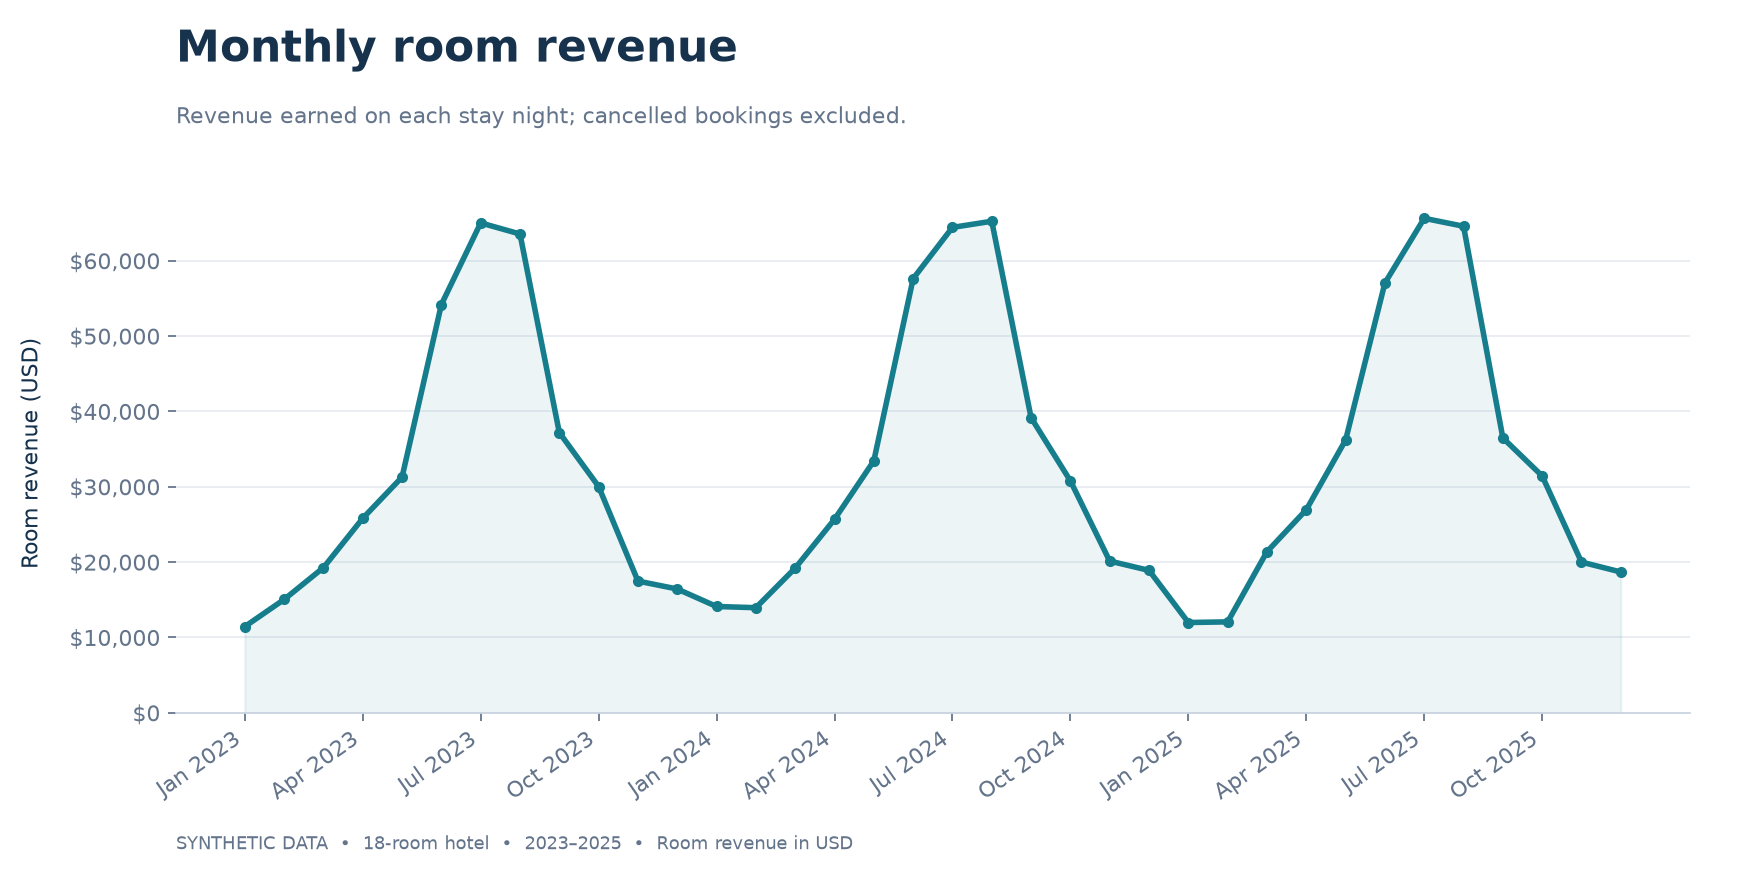

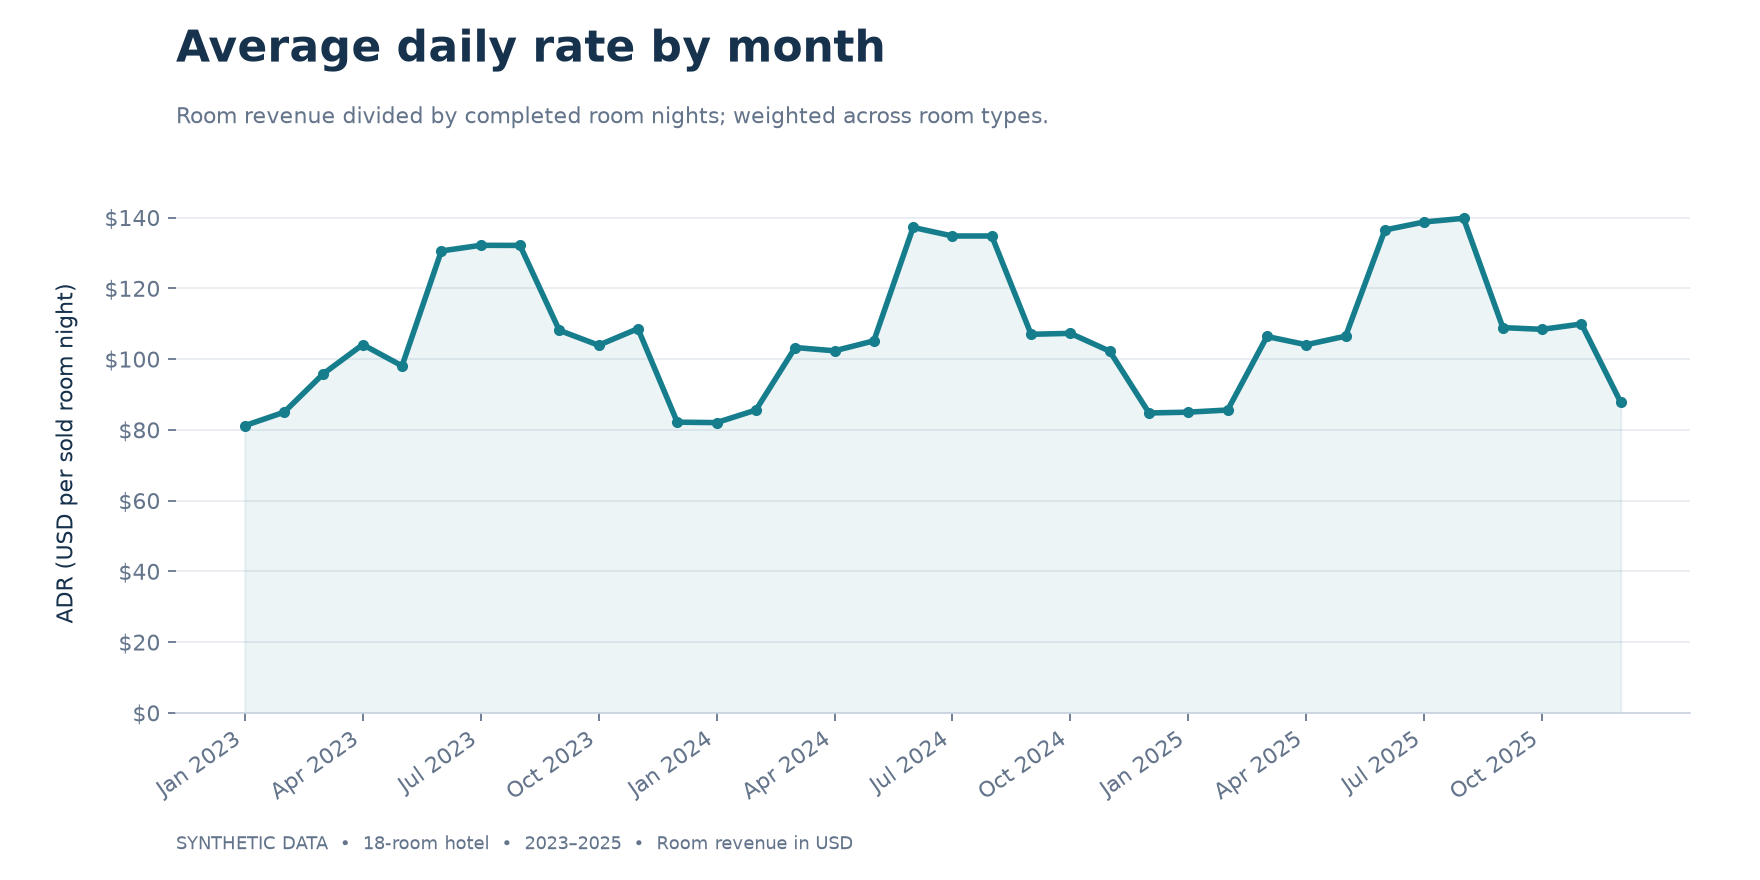

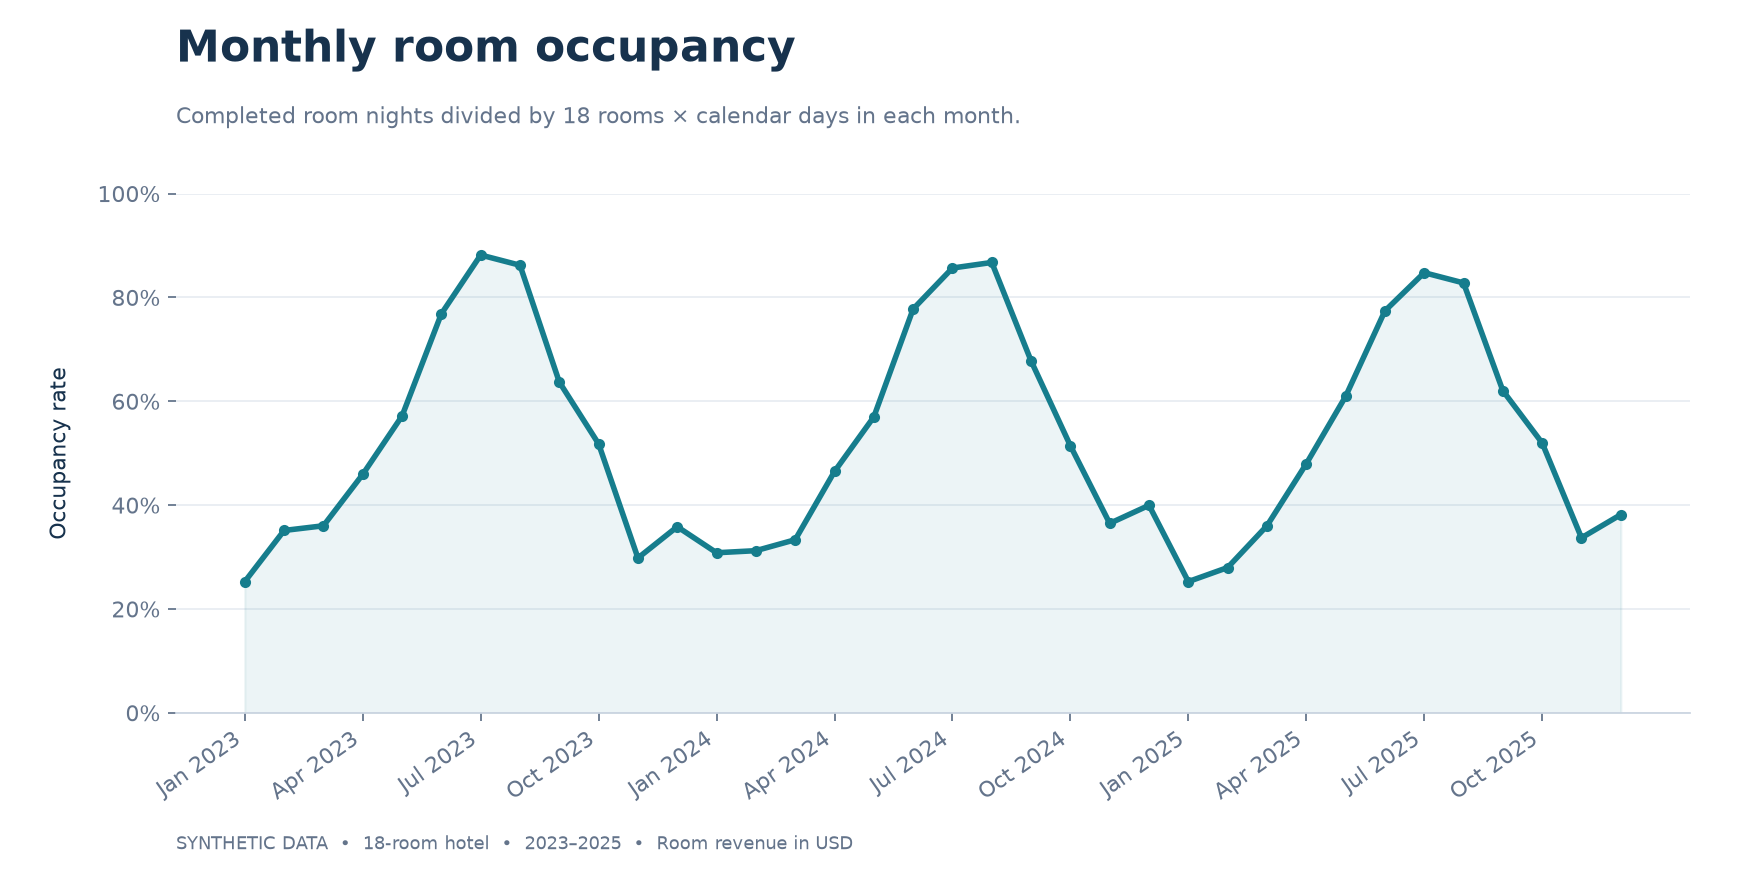

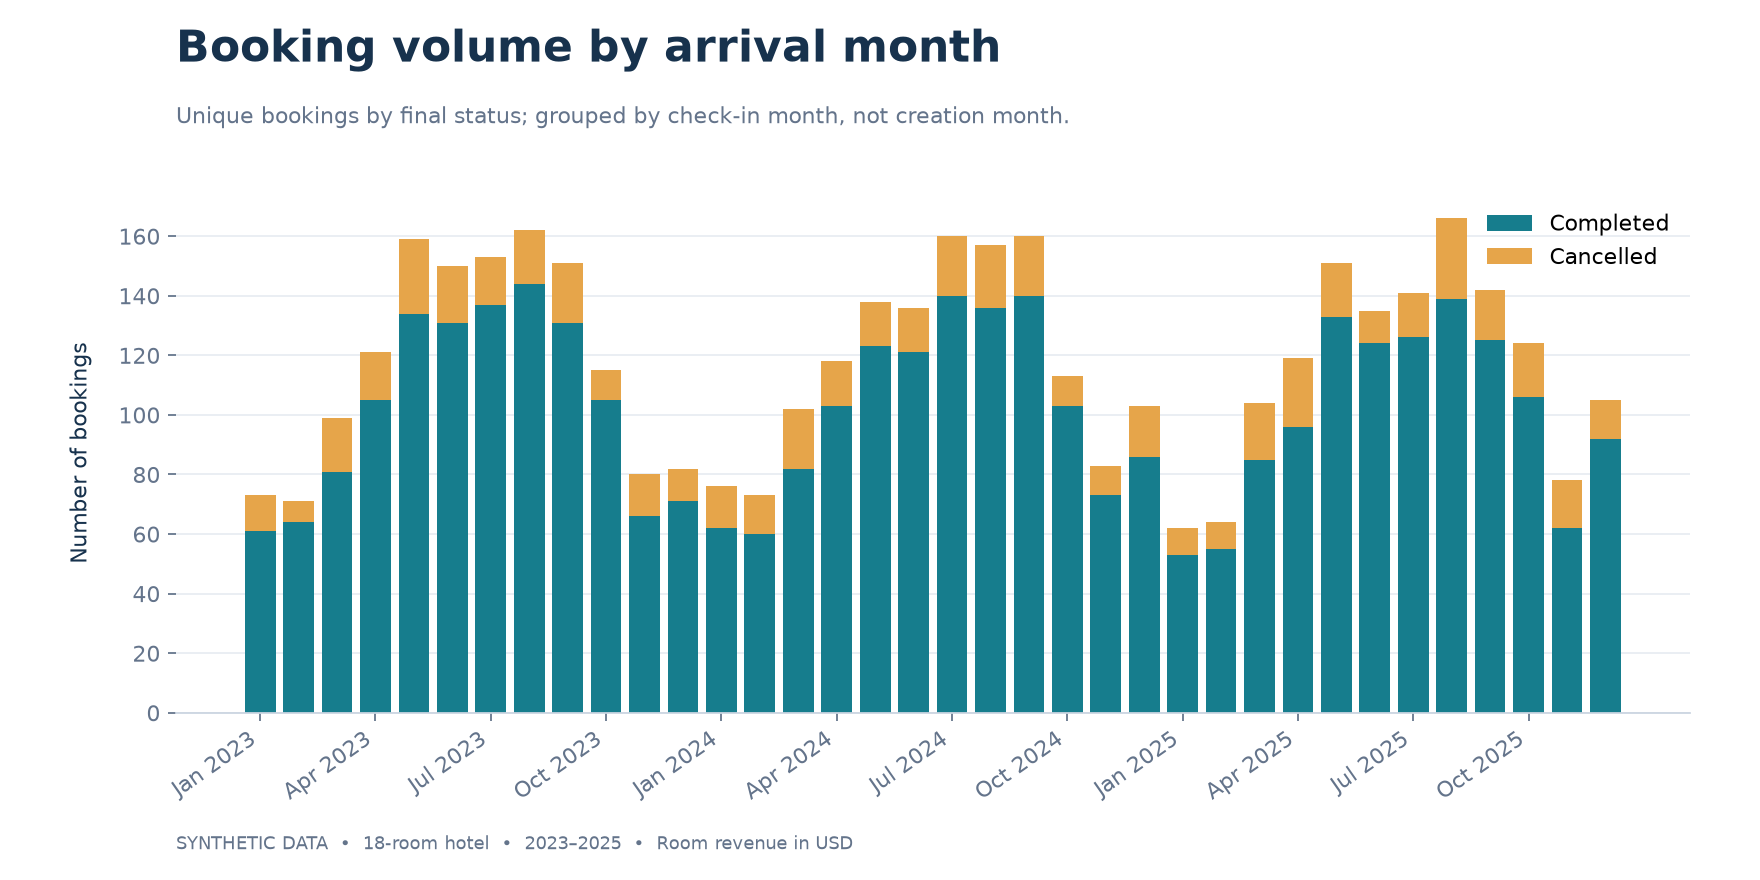

In [6]:
display(tables["monthly_performance"].round(3))
for name in ["monthly_revenue", "monthly_adr", "monthly_occupancy", "monthly_bookings"]:
    display(Image(filename=str(FIGURES_DIR / f"{name}.png"), width=880))

## 7. Compare room types fairly

Revenue share depends on both room price and inventory: there are 10 Standard rooms but only 3 Family rooms. Occupancy and RevPAR provide useful comparisons alongside revenue, ADR and completed booking volume. This analysis measures gross room revenue, not contribution margin.

,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar,revenue_share,completed_bookings,total_bookings
room_type,,,,,,,,,
Deluxe,"373,961.42",2883,5480,129.71,0.53,68.24,0.31,1010,1180
Family,"297,630.13",1709,3288,174.16,0.52,90.52,0.25,596,667
Standard,"520,235.58",5876,10960,88.54,0.54,47.47,0.44,2049,2379


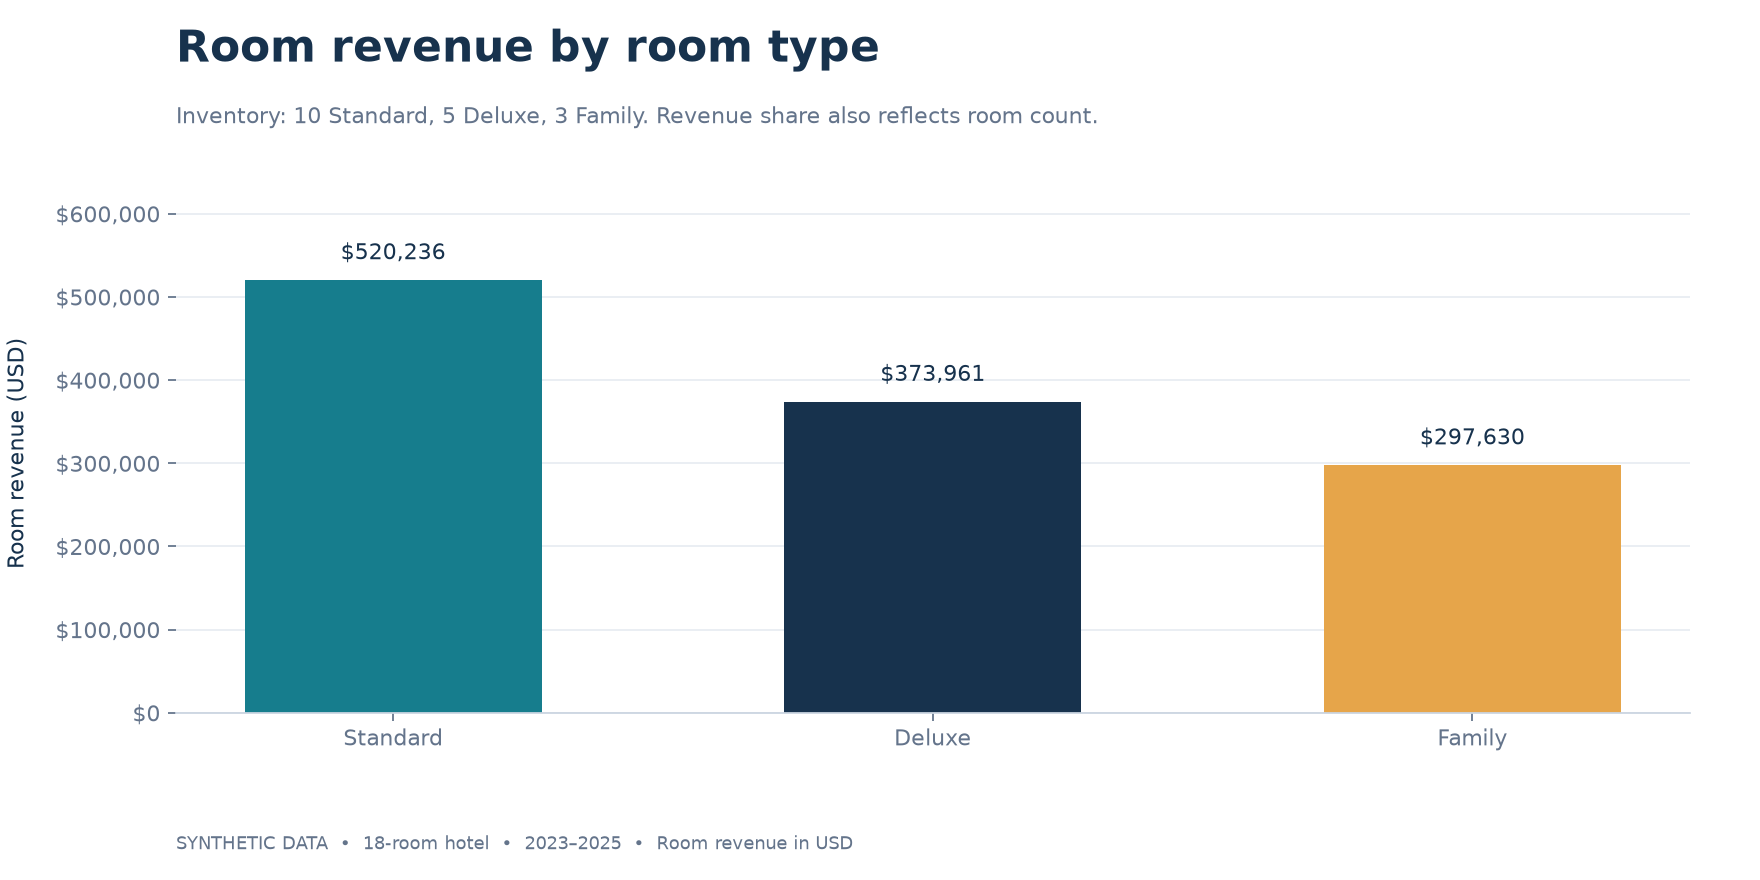

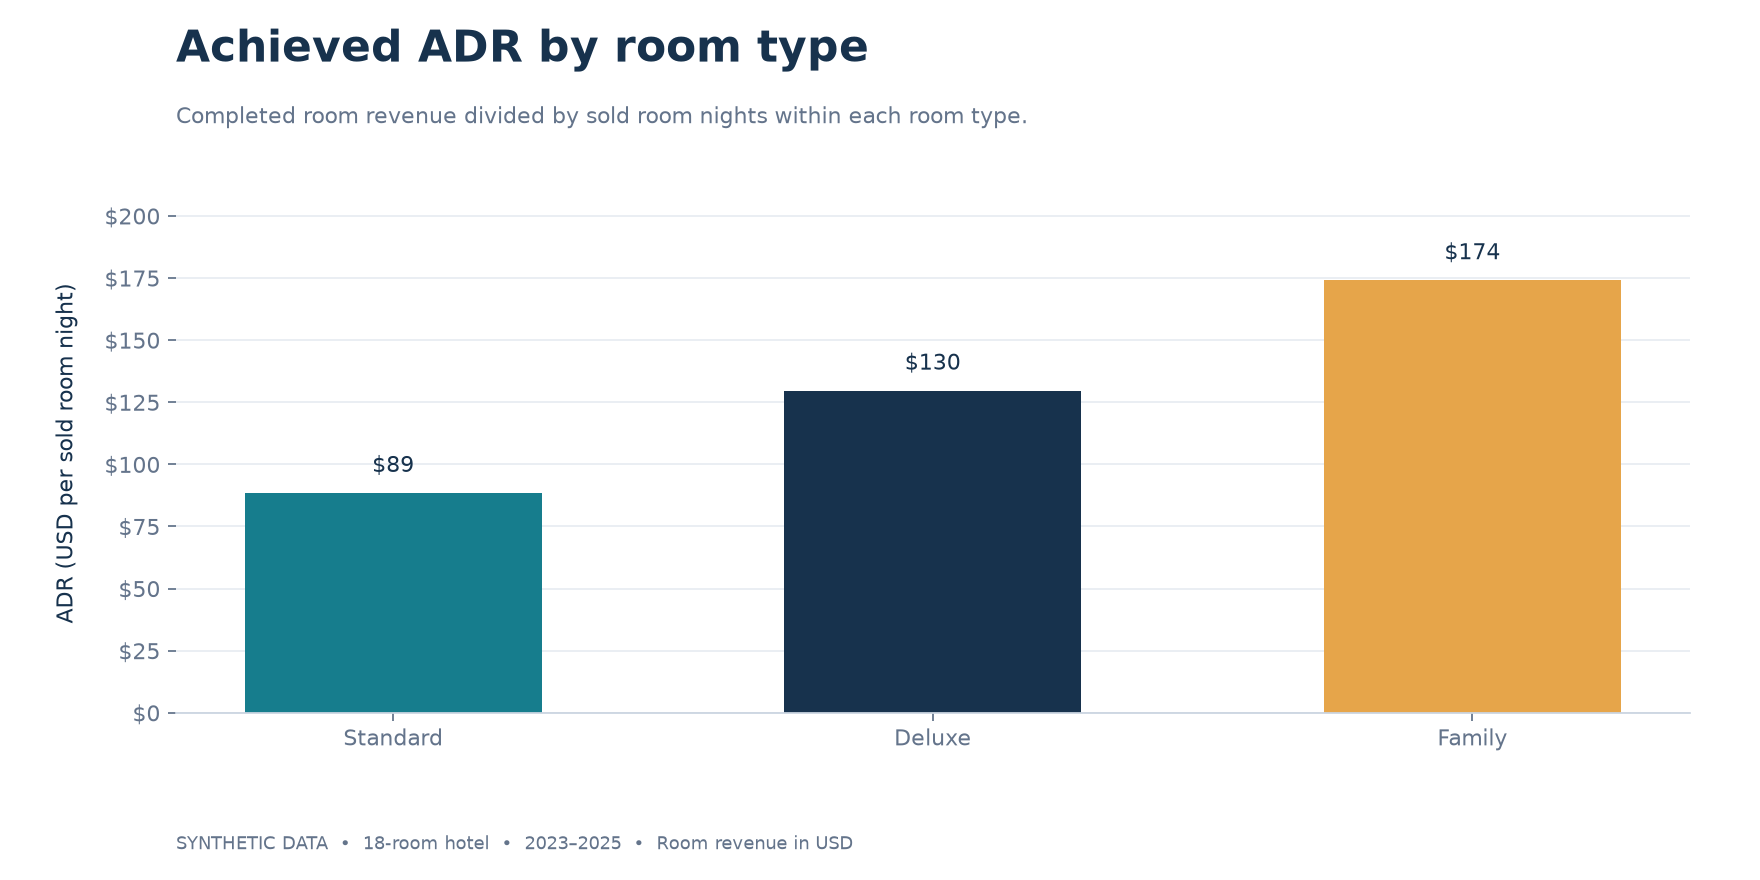

In [7]:
display(tables["room_performance"].round(3))
for name in ["room_type_revenue", "room_type_adr"]:
    display(Image(filename=str(FIGURES_DIR / f"{name}.png"), width=880))

## 8. Compare seasons and weekdays/weekends

Occupancy adjusts for different numbers of calendar days, including leap years. Weekend means Friday and Saturday stay nights; the other five nights are weekdays. Comparing raw weekend revenue against five weekdays without exposure adjustment would be misleading.

Booking-level `season` describes arrival. Nightly seasonal revenue follows the actual stay date; a stay crossing a seasonal boundary can contribute to both seasons.

,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar,total_bookings
season,,,,,,,
Winter,"132,612.67",1571,4878,84.41,0.32,27.19,709
Spring,"239,217.24",2323,4968,102.98,0.47,48.15,1111
Summer,"557,295.68",4123,4968,135.17,0.83,112.18,1360
Autumn,"262,701.54",2451,4914,107.18,0.50,53.46,1046


,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar
month_number,,,,,,
1,"37,536.60",454,1674,82.68,0.27,22.42
2,"41,058.78",481,1530,85.36,0.31,26.84
3,"59,855.13",588,1674,101.79,0.35,35.76
4,"78,445.12",758,1620,103.49,0.47,48.42
5,"100,916.99",977,1674,103.29,0.58,60.28
6,"168,860.13",1253,1620,134.76,0.77,104.23
7,"195,073.11",1443,1674,135.19,0.86,116.53
8,"193,362.44",1427,1674,135.50,0.85,115.51
9,"112,830.71",1045,1620,107.97,0.65,69.65


,revenue,room_nights,available_room_nights,adr,occupancy_rate,revpar
day_type,,,,,,
Weekday,"817,095.17",7226,14112,113.08,0.51,57.90
Weekend,"374,731.96",3242,5616,115.59,0.58,66.73


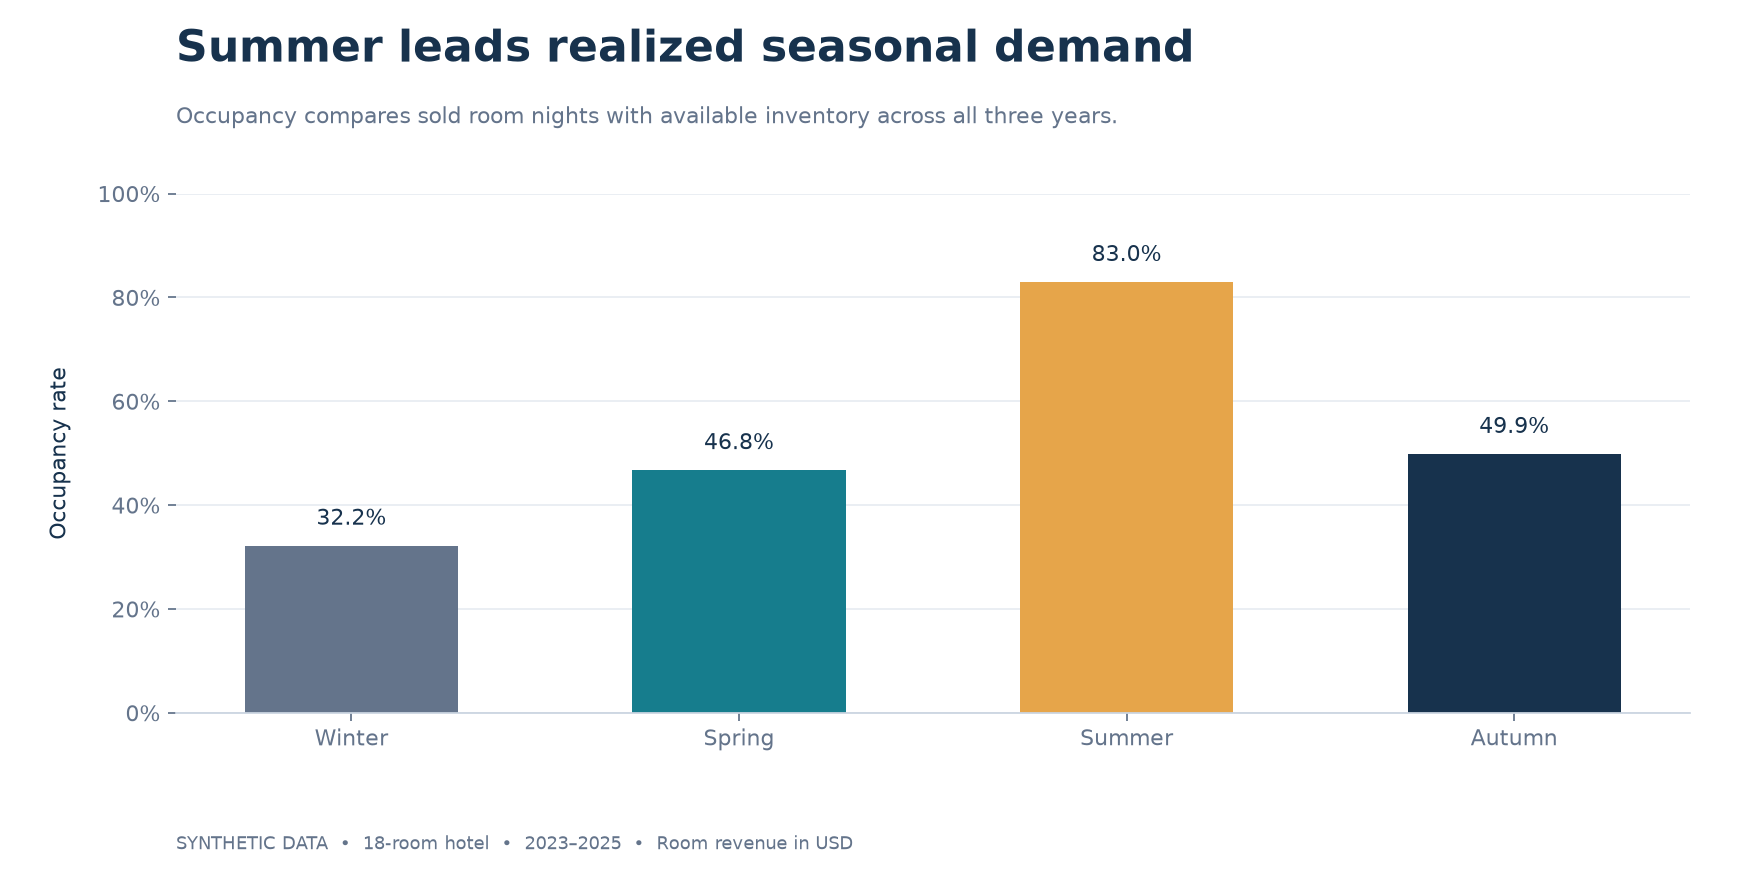

In [8]:
display(tables["seasonal_performance"].round(3))
display(tables["calendar_month_performance"].round(3))
display(tables["weekday_weekend_performance"].round(3))
display(Image(filename=str(FIGURES_DIR / "seasonal_demand.png"), width=880))

## 9. Inspect booking behavior

Lead time is measured for completed bookings. Channel cancellation rates use all unique bookings in each channel. Longer lead times can co-occur with summer demand, so an apparent lead-time pricing pattern can be confounded by season.

Creation-month counts are distinct from arrival-month counts and include some dates in 2022. They are conditioned on arrivals during the study window and should not be interpreted as a complete sales pipeline.

,total_bookings,cancellation_rate
booking_channel,,
Direct,1793,0.07
Online travel agency,2003,0.19
Travel agent,430,0.15


,nights,lead_time
room_type,,
Deluxe,2.85,27.28
Family,2.87,26.79
Standard,2.87,26.21


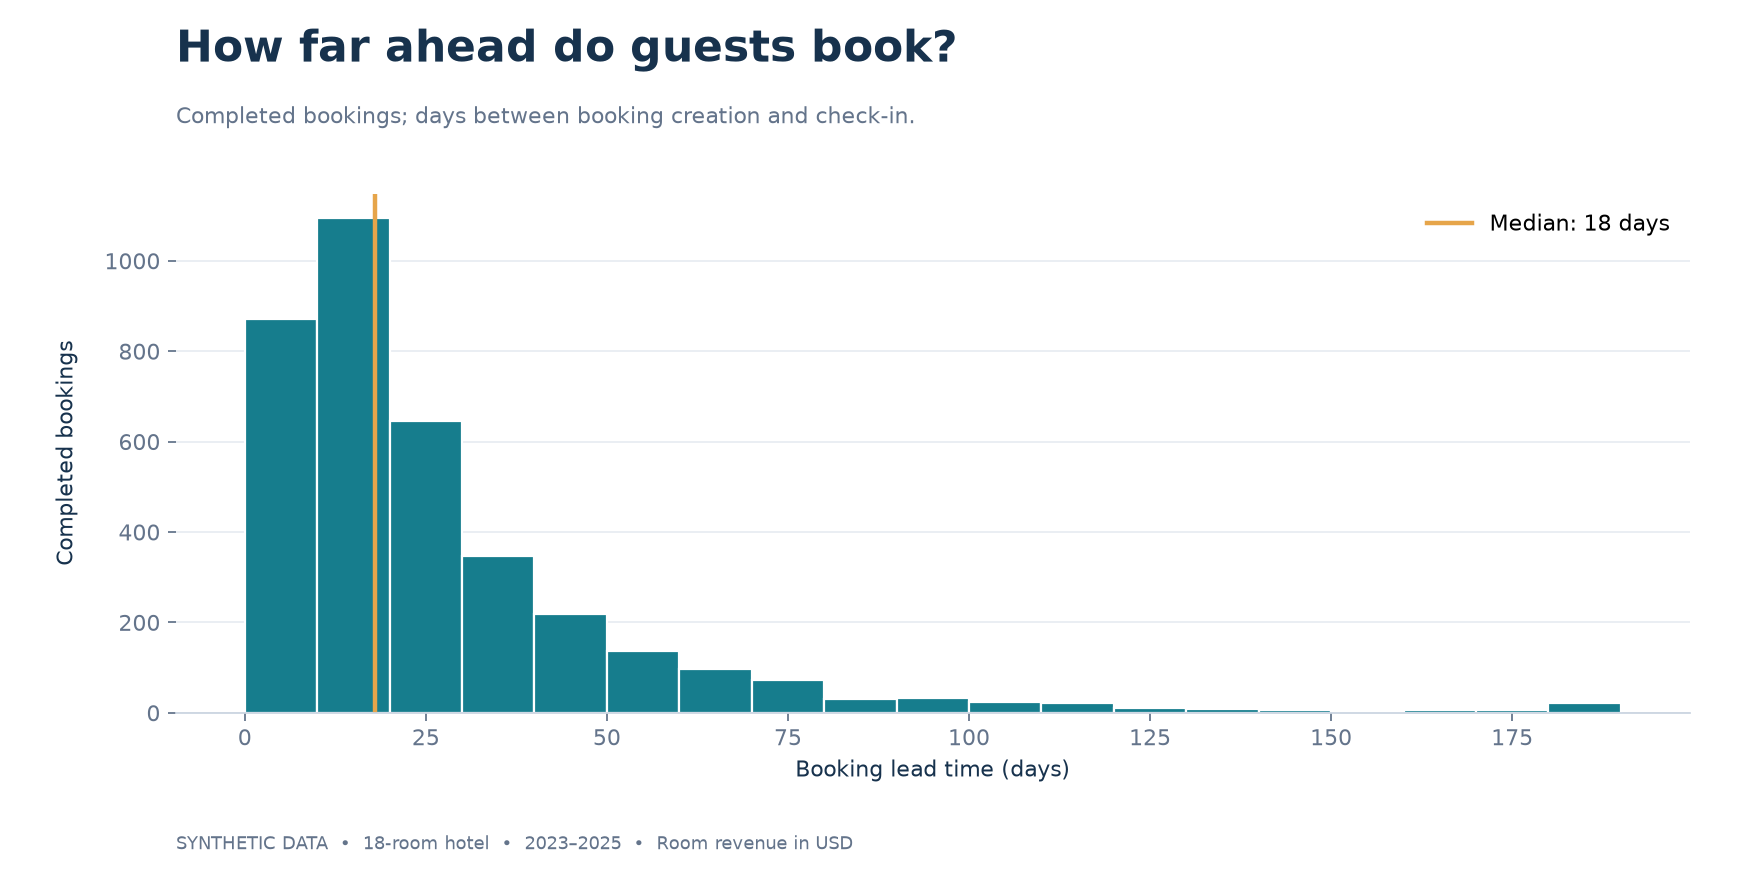

In [9]:
channels = bookings.groupby("booking_channel").agg(
    total_bookings=("booking_id", "size"),
    cancellation_rate=("booking_status", lambda values: values.eq("Cancelled").mean()),
)
display(channels.round(3))
completed = bookings.loc[bookings["booking_status"].eq("Completed")]
display(completed.groupby("room_type")[["nights", "lead_time"]].mean().round(2))
display(Image(filename=str(FIGURES_DIR / "lead_time_distribution.png"), width=880))

## 10. Evaluate pricing relationships

Compare monthly sold room nights and occupancy against ADR, rates across seasons within room type, and lead-time bands within room type. Lead-time ADR is weighted by sold room nights. The tables include sample sizes so sparse comparisons are visible.

**Interpretation limit:** seasonality drives both demand and prices by design. Pearson correlations describe that simulated association; they do not show that increasing prices increases demand. Within-room-type comparisons reduce room-mix distortion but do not eliminate seasonality or other confounding. No price elasticity model or automated dynamic-pricing engine is fitted.

,pearson_r,observations
relationship,,
Monthly occupancy vs ADR,0.90,36
Monthly sold room nights vs ADR,0.89,36
Completed booking lead time vs quoted nightly rate,0.12,3655


revenue  room_nights  available_room_nights    adr  \
season room_type                                                         
Autumn Deluxe     83,417.86          674                   1365 123.77   
       Family     61,303.16          377                    819 162.61   
       Standard  117,980.52         1400                   2730  84.27   
Spring Deluxe     73,306.45          619                   1380 118.43   
       Family     59,804.37          383                    828 156.15   
       Standard  106,106.42         1321                   2760  80.32   
Summer Deluxe    172,087.93         1129                   1380 152.43   
       Family    148,923.02          735                    828 202.62   
       Standard  236,284.73         2259                   2760 104.60   
Winter Deluxe     45,149.18          461                   1355  97.94   
       Family     27,599.58          214                    813 128.97   
       Standard   59,863.91          896                   2710  66.81   

                  occupancy_rate  revpar  
season room_type                          
Autumn Deluxe               0.49   61.11  
       Family               0.46   74.85  
       Standard             0.51   43.22  
Spring Deluxe               0.45   53.12  
       Family               0.46   72.23  
       Standard             0.48   38.44  
Summer Deluxe               0.82  124.70  
       Family               0.89  179.86  
       Standard             0.82   85.61  
Winter Deluxe               0.34   33.32  
       Family               0.26   33.95  
       Standard             0.33   22.09

completed_bookings  room_nights    revenue    adr
room_type lead_time_band                                                   
Deluxe    0–7 days                       163          433  52,297.31 120.78
          8–30 days                      575         1641 210,692.65 128.39
          31–60 days                     171          499  68,163.43 136.60
          61+ days                       101          310  42,808.03 138.09
Family    0–7 days                        92          212  34,209.14 161.36
          8–30 days                      335          992 170,231.04 171.60
          31–60 days                     123          355  66,158.48 186.36
          61+ days                        46          150  27,031.47 180.21
Standard  0–7 days                       341          926  76,481.27  82.59
          8–30 days                     1154         3271 287,951.54  88.03
          31–60 days                     367         1073  99,793.09  93.00
          61+ days                       187          606  56,009.68  92.42

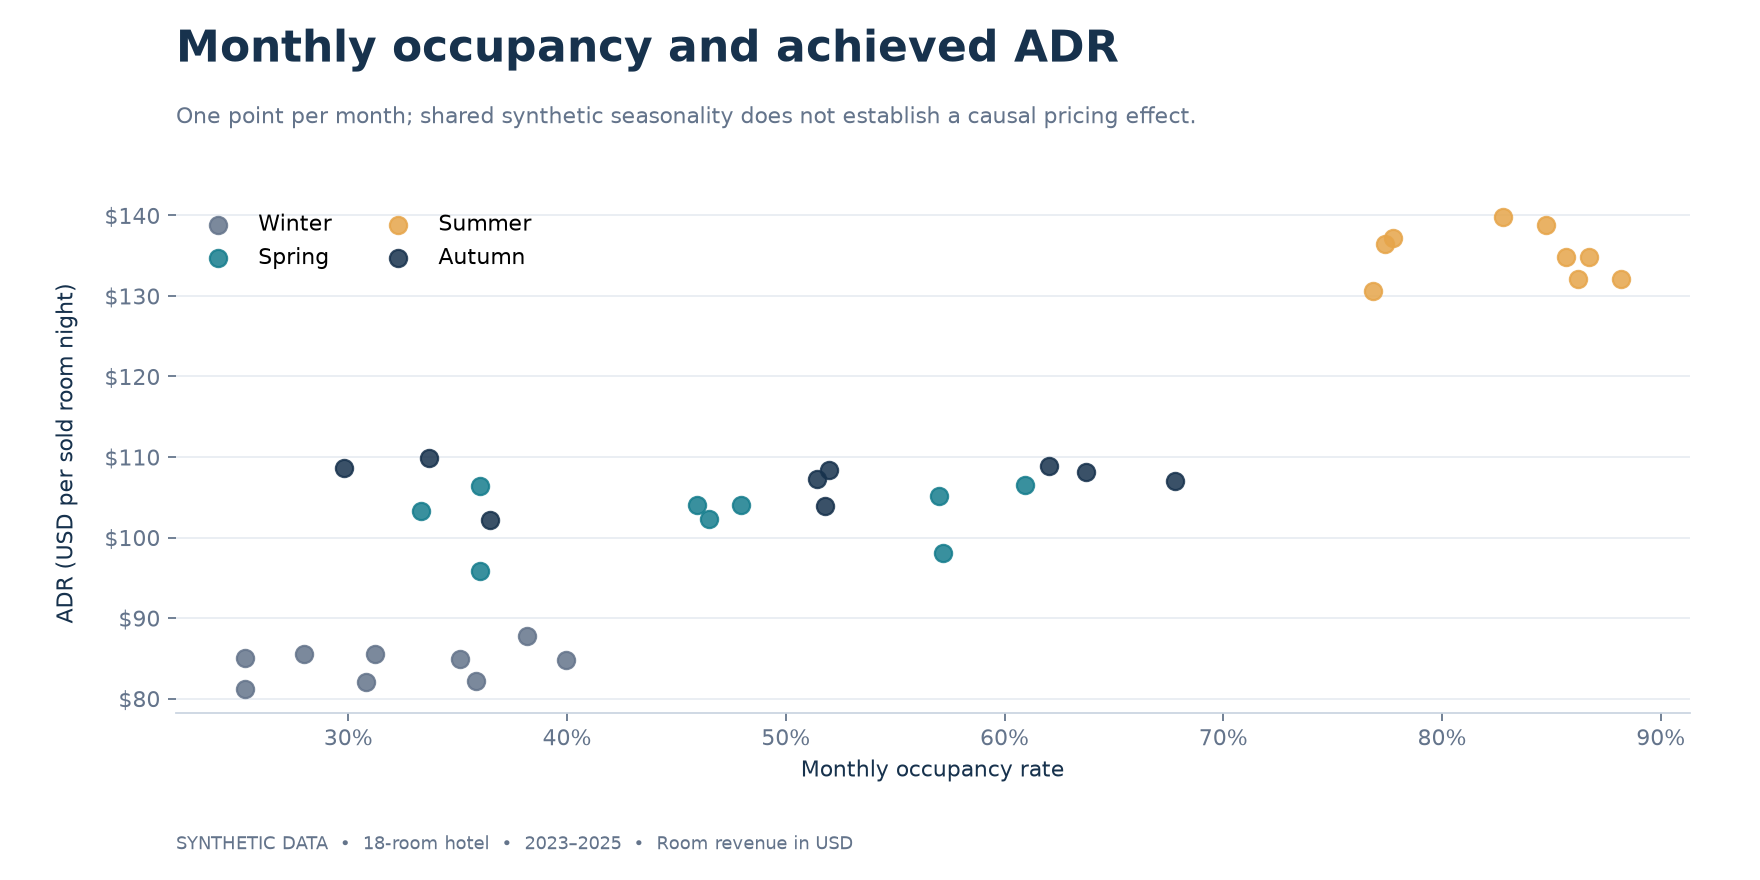

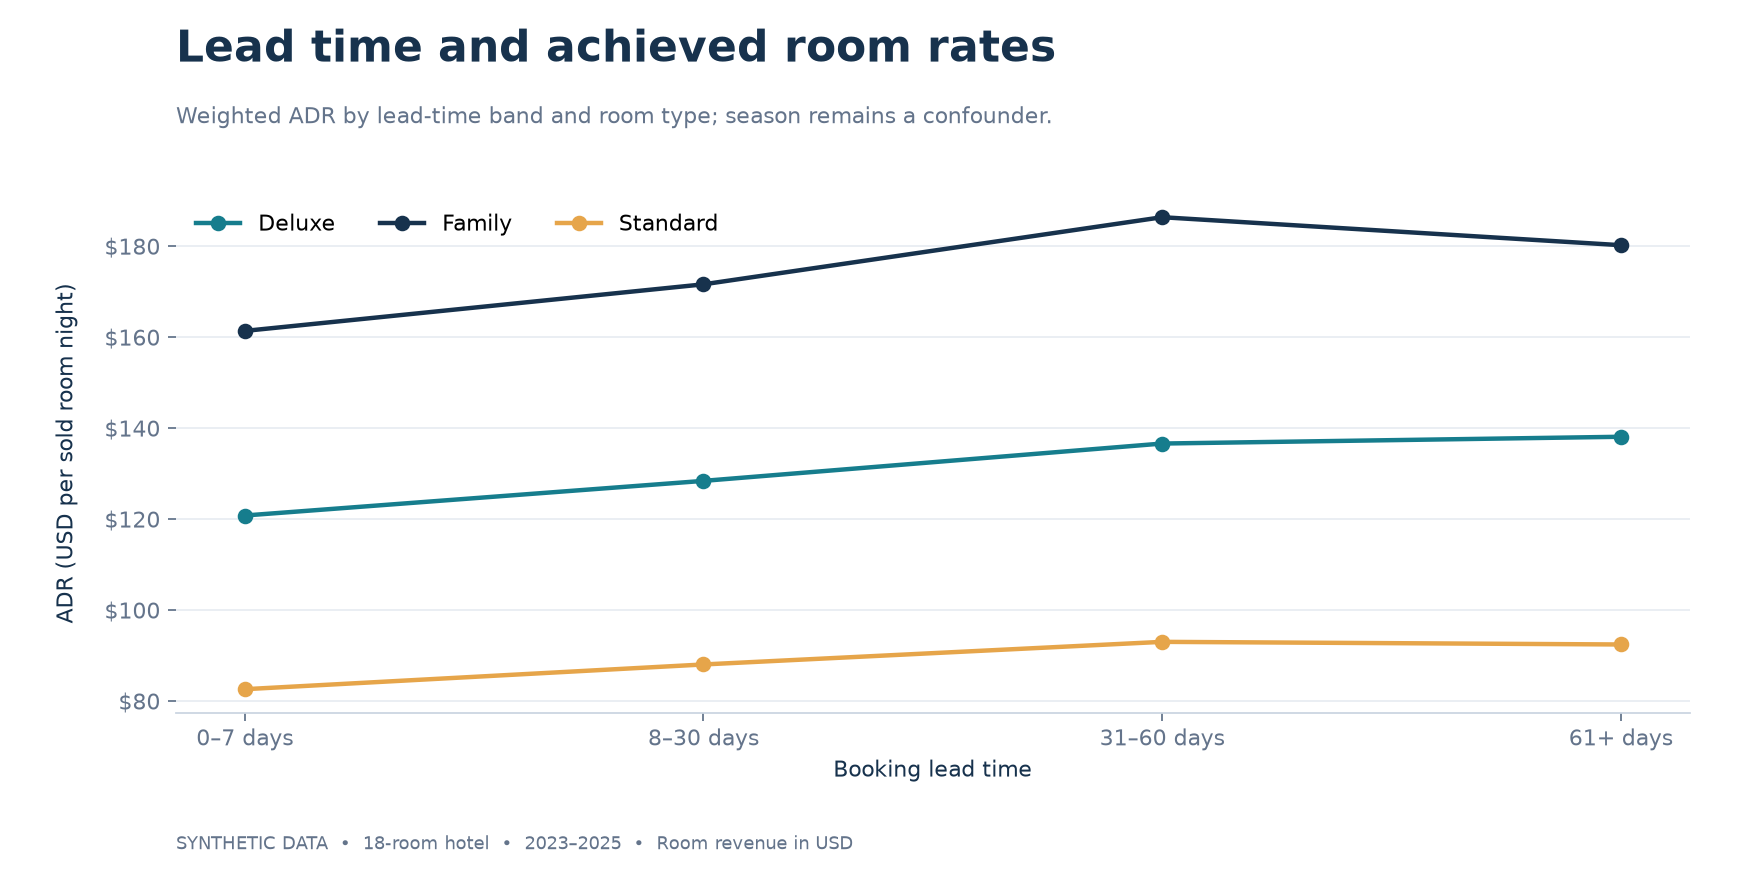

In [10]:
display(tables["pricing_correlations"].round(3))
display(tables["pricing_by_season_room"].round(3))
display(tables["pricing_by_lead_time"].round(3))
for name in ["occupancy_vs_adr", "lead_time_vs_adr"]:
    display(Image(filename=str(FIGURES_DIR / f"{name}.png"), width=880))

## 11. Turn findings into testable recommendations

The statements below are derived from the current results. High-occupancy pricing and low-occupancy promotion suggestions are conditional, illustrative hypotheses. They do not promise a revenue uplift or claim proven business impact.

In [11]:
insights = business_insights(kpis, tables)
display(Markdown("\n\n".join(f"- {insight}" for insight in insights)))

- 2025-07 generated the most monthly room revenue ($65,628.32). Revenue is allocated by stay night, including stays crossing month-end.

- Summer had the highest occupancy (83.0%) at $135.17 ADR; Winter had the lowest (32.2%) at $84.41 ADR.

- Standard rooms generated 43.7% of room revenue ($520,235.58). Compare their 53.6% occupancy and $47.47 RevPAR alongside revenue share because room counts differ.

- 13.5% of unique bookings were cancelled. Completed stays averaged 2.86 nights and were booked 26.6 days ahead.

- Pricing hypothesis: with summer occupancy at 83.0%, test a small rate increase on selected busy dates and monitor conversion, cancellations and RevPAR. The data does not estimate an optimal price or uplift.

- Promotion hypothesis: winter occupancy of 32.2% suggests testing targeted packages on weak dates. Evaluate incremental room nights and net revenue after discount and channel costs, which are not modeled here.

- Monthly occupancy and ADR have a Pearson correlation of 0.90. Both share an explicitly programmed seasonal pattern; this is descriptive and cannot show that raising prices causes stronger demand.

## 12. What this project can and cannot demonstrate

The project demonstrates a reproducible cleaning and analytics workflow, correct nightly accounting, defensible capacity denominators, clear visuals and supported business communication. All data and simulation parameters are artificial.

A real follow-up would need authorized inventory availability, cancellation timestamps, channel costs and demand/conversion measures to assess profitability and price sensitivity. Here, costs and rejected demand are unavailable; cancellations never hold inventory; the first day starts without carry-in guests and final-year stays are shortened at the reporting boundary. These choices limit operational realism.

Rebuild all committed outputs with `python -m src.run_analysis`; validate accounting and simulation properties with `python -m unittest discover -s tests -v`.

> This repository contains no real customer, reservation, Booking.com, or business data. All data is synthetically generated for portfolio and demonstration purposes.